In [1]:
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
import plotly.graph_objects as go



# The Lorenz equations

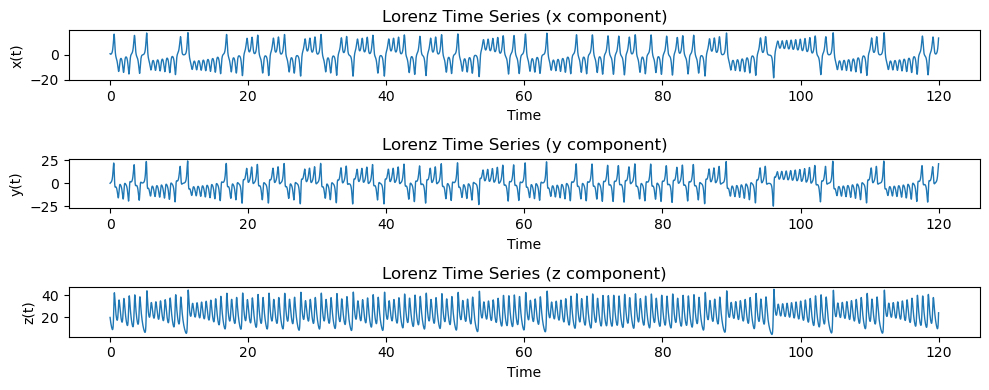

In [2]:

# Lorenz system
def lorenz(t, state, sigma=10.0, beta=8/3, rho=28.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

# Time grid
t_start, t_end = 0.0,120.0
dt = 0.01
t_eval = np.arange(t_start, t_end, dt)

# Initial condition
y0 = [1.0, 0.0, 20.0]

# Solve ODE
sol = solve_ivp(lorenz, (t_start, t_end), y0, t_eval=t_eval, rtol=1e-9, atol=1e-12)

# Time series (use x as observed scalar series for Takens embedding)
t = sol.t
x_lorenz, y_lorenz, z_lorenz = sol.y


# Quick plot of the observed series
fig, axs = plt.subplots(3, 1, figsize=(10, 4))
axs[0].plot(t, x_lorenz, lw=1)
axs[0].set_xlabel("Time")
axs[0].set_ylabel("x(t)")
axs[0].set_title("Lorenz Time Series (x component)")
axs[1].plot(t, y_lorenz, lw=1)
axs[1].set_xlabel("Time")
axs[1].set_ylabel("y(t)")
axs[1].set_title("Lorenz Time Series (y component)")
axs[2].plot(t, z_lorenz, lw=1)
axs[2].set_xlabel("Time")
axs[2].set_ylabel("z(t)")
axs[2].set_title("Lorenz Time Series (z component)")

plt.tight_layout()
plt.show()

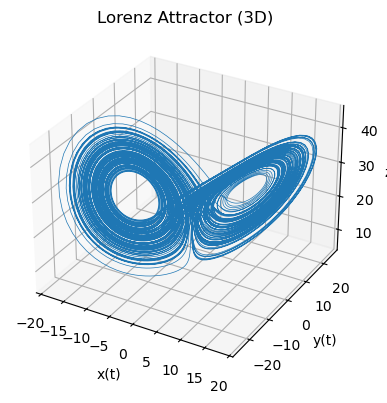

In [3]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x_lorenz, y_lorenz, z_lorenz, lw=0.5)

ax.set_xlabel("x(t)")
ax.set_ylabel("y(t)")
ax.set_zlabel("z(t)")
ax.set_title("Lorenz Attractor (3D)")

plt.tight_layout()
plt.show()

In [4]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x_lorenz,
            y=y_lorenz,
            z=z_lorenz,
            mode="markers",
            marker=dict(
                size=2,
                color=np.arange(len(x_lorenz)),  # color by index
                colorbar=dict(title="index"),
                colorscale="Viridis",
                opacity=0.6,
            ),
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title='x(t)',
        yaxis_title='x(t-τ)',
        zaxis_title='x(t-2τ)'
    ),
    title='Lorenz  (interactive)',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

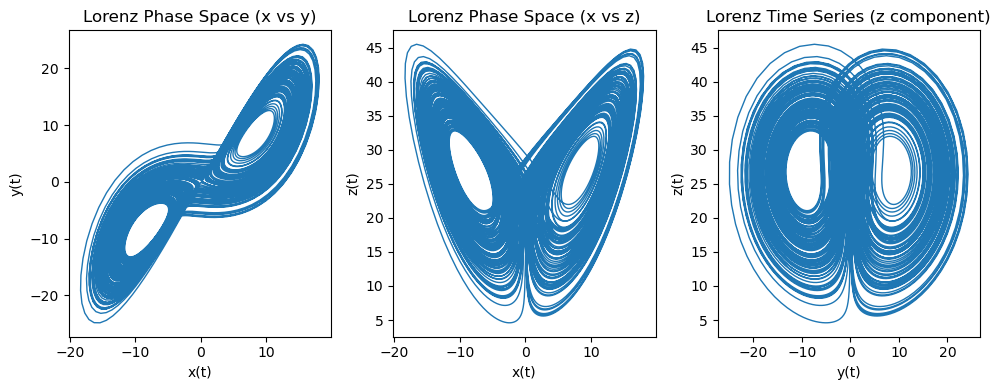

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))
axs[0].plot( x_lorenz,y_lorenz, lw=1)
axs[0].set_xlabel("x(t)")
axs[0].set_ylabel("y(t)")
axs[0].set_title("Lorenz Phase Space (x vs y)")
axs[1].plot(x_lorenz, z_lorenz, lw=1)
axs[1].set_xlabel("x(t)")
axs[1].set_ylabel("z(t)")
axs[1].set_title("Lorenz Phase Space (x vs z)")
axs[2].plot(y_lorenz, z_lorenz, lw=1)
axs[2].set_xlabel("y(t)")
axs[2].set_ylabel("z(t)")
axs[2].set_title("Lorenz Phase Space (y vs z)")
axs[2].set_ylabel("z(t)")
axs[2].set_title("Lorenz Time Series (z component)")

plt.tight_layout()
plt.show()

## Delay plotting

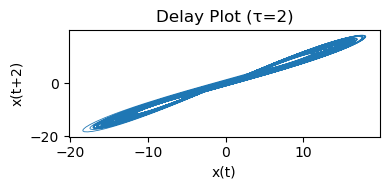

In [6]:
ts=x_lorenz
tau=2
plt.figure(figsize=(4, 2))
plt.plot( ts[:-tau], ts[tau:], lw=0.6)
plt.xlabel("x(t)")
plt.ylabel(f"x(t+{tau})")
plt.title(f"Delay Plot (τ={tau})")
plt.tight_layout()
plt.show()


# Takens Embedding (Short Intro)

Takens embedding is a method for reconstructing the hidden state space of a dynamical system from a single observed time series.  
Instead of measuring all system variables, it builds vectors of delayed samples:

$$
\mathbf{y}(t) = [x(t), x(t-\tau), x(t-2\tau), \dots, x(t-(m-1)\tau)]
$$

where $\tau$ is the delay and $m$ is the embedding dimension.  
Under suitable conditions, this reconstructed space preserves the geometry of the original dynamics, making it useful for analyzing chaos, attractors, and nonlinear time-series structure.


See this: https://verzep.github.io/Takens/

### The delay routine

In [7]:
def delay_embedding(x, tau, m):
    """
    Delay-coordinate embedding
    x   : scalar time series
    tau : delay (in samples)
    m   : embedding dimension
    """
    N = len(x) - (m - 1) * tau # number of rows in the embedded space
    Y = np.zeros((N, m)) # embedded data matrix
    for i in range(m):
        
        Y[:, i] = x[i * tau : i * tau + N] # fill column i with the delayed version of x
    return Y

In [8]:
# Simple examples to illustrate how delay_embedding builds vectors
example_ts = np.arange(10)

print("Original series:")
print(example_ts)

print("\nExample 1: tau=1, m=3")
Y_ex1 = delay_embedding(example_ts, tau=1, m=3)
print(Y_ex1)

tau=2
m=4
print(f"\nExample 2: tau={tau}, m={m}")
Y_ex2 = delay_embedding(example_ts, tau=tau, m=m)
print(Y_ex2)






Original series:
[0 1 2 3 4 5 6 7 8 9]

Example 1: tau=1, m=3
[[0. 1. 2.]
 [1. 2. 3.]
 [2. 3. 4.]
 [3. 4. 5.]
 [4. 5. 6.]
 [5. 6. 7.]
 [6. 7. 8.]
 [7. 8. 9.]]

Example 2: tau=2, m=4
[[0. 2. 4. 6.]
 [1. 3. 5. 7.]
 [2. 4. 6. 8.]
 [3. 5. 7. 9.]]


## Selecting delay

#### Autocorrelation
**Autocorrelation equations**

For a discrete time series $x_t,\; t=0,\dots,N-1$, define

$$
\mu = \frac{1}{N}\sum_{t=0}^{N-1} x_t,
\qquad
\sigma^2 = \frac{1}{N}\sum_{t=0}^{N-1}(x_t-\mu)^2.
$$

A standardized series is

$$
\tilde{x}_t=\frac{x_t-\mu}{\sigma}.
$$

The (sample) autocorrelation at lag $\tau$ is
$$ 
R_{xx}(\tau)
=
\frac{\sum_{t=0}^{N-\tau-1}(x_t-\mu)(x_{t+\tau}-\mu)}
{\sum_{t=0}^{N-1}(x_t-\mu)^2},
\qquad \tau=0,1,2,\dots
$$

Equivalent form using standardized data:

$$
R_{xx}(\tau)
=
\frac{1}{N-\tau}\sum_{t=0}^{N-\tau-1}\tilde{x}_t\,\tilde{x}_{t+\tau}.
$$

With this normalization, $R_{xx}(0)=1$.

In [9]:
def autocorrelation(x, max_lag):
    """
    Compute the normalized autocorrelation function (ACF) for a 1D signal.

    Parameters
    ----------
    x : array-like
        Input time series.
    max_lag : int
        Number of non-negative lags to return (starting at lag 0).

    Returns
    -------
    np.ndarray
        ACF values from lag 0 up to lag `max_lag - 1`, normalized so ACF[0] = 1.
    """
    x = np.asarray(x, dtype=float).ravel()

    if x.size == 0:
        raise ValueError("x must contain at least one sample.")

    max_lag = int(max_lag)
    if max_lag <= 0:
        raise ValueError("max_lag must be a positive integer.")

    max_lag = min(max_lag, x.size)
    x = (x - x.mean()) / x.std() if x.std() != 0 else x - x.mean() # normalize to zero mean and unit variance
    ac = np.correlate(x, x, mode='full') # compute autocorrelation
    ac = ac[ac.size // 2:] # take the second half (non-negative lags)
    return ac[:max_lag] / ac[0] # normalize by zero-lag value



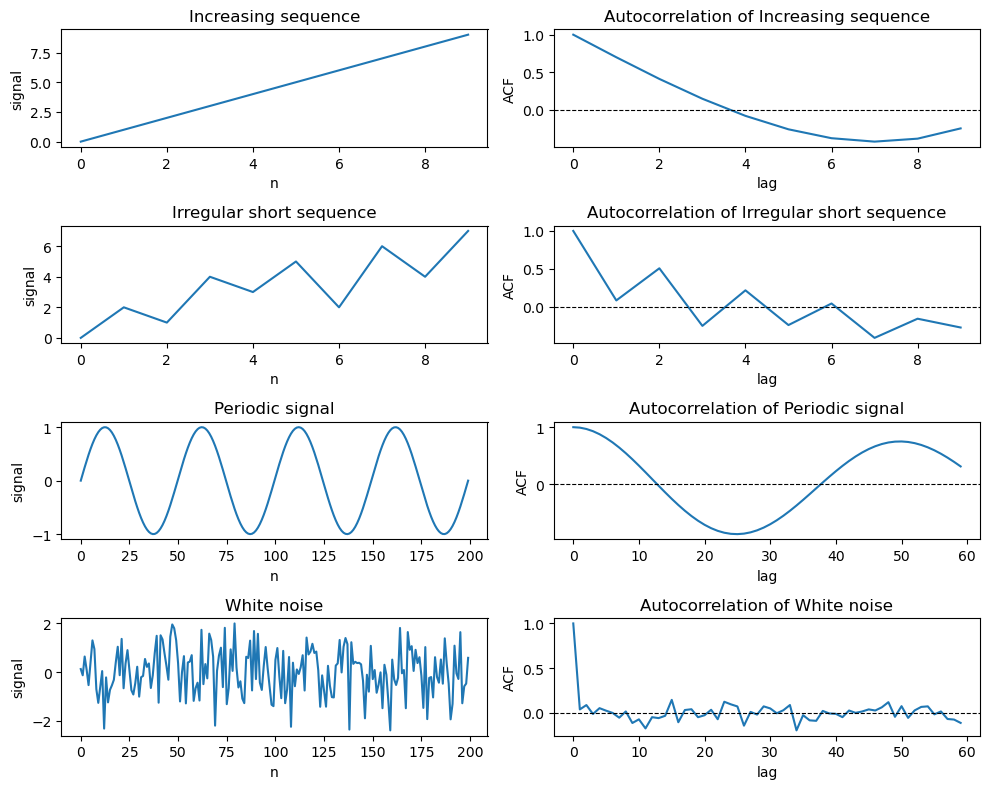

In [10]:
# Illustrative examples of the autocorrelation function

# Define missing example signal
example_ts2 = np.array([0, 2, 1, 4, 3, 5, 2, 6, 4, 7], dtype=float)

toy_signals = {
    "Increasing sequence": example_ts.astype(float),
    "Irregular short sequence": example_ts2,
    "Periodic signal": np.sin(np.linspace(0, 8 * np.pi, 200)),
    "White noise": np.random.default_rng(0).normal(size=200),
}

fig, axes = plt.subplots(len(toy_signals), 2, figsize=(10, 8))

for row, (name, s) in enumerate(toy_signals.items()):
    toy_max_lag = min(len(s), 60)
    toy_ac = autocorrelation(s, toy_max_lag)

    axes[row, 0].plot(s, lw=1.5)
    axes[row, 0].set_title(name)
    axes[row, 0].set_xlabel("n")
    axes[row, 0].set_ylabel("signal")

    axes[row, 1].plot(range(toy_max_lag), toy_ac, lw=1.5)
    axes[row, 1].axhline(0, color="k", linestyle="--", lw=0.8)
    axes[row, 1].set_title(f"Autocorrelation of {name}")
    axes[row, 1].set_xlabel("lag")
    axes[row, 1].set_ylabel("ACF")

plt.tight_layout()
plt.show()

Used on Lorenz

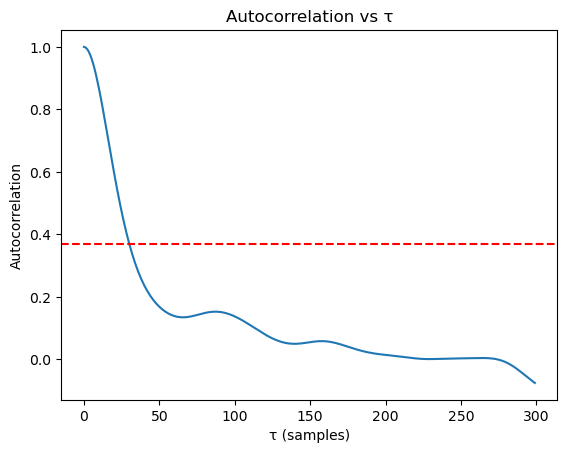

In [11]:


max_lag = 300
ts=x_lorenz # normalize to zero mean and unit variance
ac = autocorrelation(ts, max_lag)

plt.plot(ac)
plt.axhline(1/np.e, color='r', linestyle='--') # horizontal line at 1/e
plt.xlabel("τ (samples)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation vs τ")
plt.show()

**Task 1:** Find the first minimum and the first crossing of the x-axis. 

**Task 2** Plot the delay plot with these delays. 

In [12]:
# First local minimum of autocorrelation ac
d1 = np.diff(ac)
min_idx = np.where((d1[:-1] < 0) & (d1[1:] > 0))[0] + 1

if len(min_idx) == 0:
    print("No local minimum found.")
else:
    first_min = int(min_idx[0])
    print(f"First local minimum lag: {first_min}")
    print(f"ac[{first_min}] = {ac[first_min]:.5f}")
    print(f"Delay in time units: {first_min * dt:.2f}")

# First crossing of 0 (from positive to non-positive)
zc_idx = np.where((ac[:-1] > 0) & (ac[1:] <= 0))[0]

if len(zc_idx) == 0:
    print("No zero crossing found.")
else:
    i = int(zc_idx[0])
    # Linear interpolation for a more precise crossing lag
    frac = ac[i] / (ac[i] - ac[i + 1])
    zero_lag = i + frac

    print(f"First zero crossing between lags {i} and {i+1}")
    print(f"Approx zero-crossing lag: {zero_lag:.3f}")
    print(f"Approx crossing time: {zero_lag * dt:.3f}")

First local minimum lag: 66
ac[66] = 0.13449
Delay in time units: 0.66
First zero crossing between lags 273 and 274
Approx zero-crossing lag: 273.992
Approx crossing time: 2.740


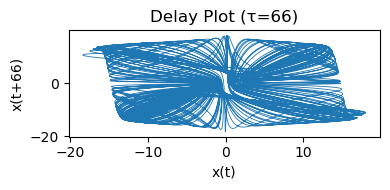

In [13]:
tau=66
plt.figure(figsize=(4, 2))
plt.plot( ts[:-tau], ts[tau:], lw=0.6)
plt.xlabel("x(t)")
plt.ylabel(f"x(t+{tau})")
plt.title(f"Delay Plot (τ={tau})")
plt.tight_layout()
plt.show()


## Mutual Information and `mutual_info_score`

### Mutual Information (MI)

For two discrete random variables $X$ and $Y$, the mutual information is

$$
I(X;Y)=\sum_{x}\sum_{y} p(x,y)\,\log\!\left(\frac{p(x,y)}{p(x)\,p(y)}\right).
$$

For delay analysis in a time series, use $X=x_t$ and $Y=x_{t+\tau}$:

$$
I(\tau)=I(x_t;\,x_{t+\tau}).
$$

 **Interpretation**

- $p(x,y)$: joint probability of observing $X=x$ and $Y=y$ together  
- $p(x)p(y)$: probability expected if $X$ and $Y$ were independent  
- The log-ratio compares **observed dependence** vs **independence**

So MI measures how much knowing one variable reduces uncertainty about the other.

- $I(X;Y)=0$: independent variables  
- Larger $I(X;Y)$: stronger dependence (linear or nonlinear)


### mutual_info_score from _sklearn.metrics_
`mutual_info_score` is a function from `sklearn.metrics` that measures how much information two variables share.  
If two variables are independent, their mutual information is close to $0$.  
If knowing one variable reduces uncertainty about the other, the mutual information is larger.

For a time series, this is useful because it can detect **nonlinear dependence** between delayed values, not only linear correlation.  
That makes it a common tool for choosing a delay $\tau$ in Takens embedding.

For a signal $x(t)$, one compares:

- $x(t)$
- $x(t+\tau)$

and computes their mutual information for different delays $\tau$.

### Why binning is needed

`mutual_info_score` works on **discrete labels**, not directly on continuous floating-point data.  
So for continuous signals, the data must first be divided into bins, and each sample is replaced by its bin index.

### In this notebook

The idea is:

1. Take the scalar observable, such as `x_lorenz`
2. Form delayed pairs $(x(t), x(t+\tau))$
3. Discretize both coordinates into bins
4. Compute mutual information with `mutual_info_score`
5. Repeat for many delays

The **first local minimum** of the average mutual information is often used as a practical choice for the embedding delay.

### Compared with autocorrelation

- **Autocorrelation** measures mainly linear dependence
- **Mutual information** can capture both linear and nonlinear dependence

This is why mutual information is often preferred when analyzing chaotic or nonlinear systems such as the Lorenz attractor.

In [14]:
from sklearn.metrics import mutual_info_score
# help(mutual_info_score)

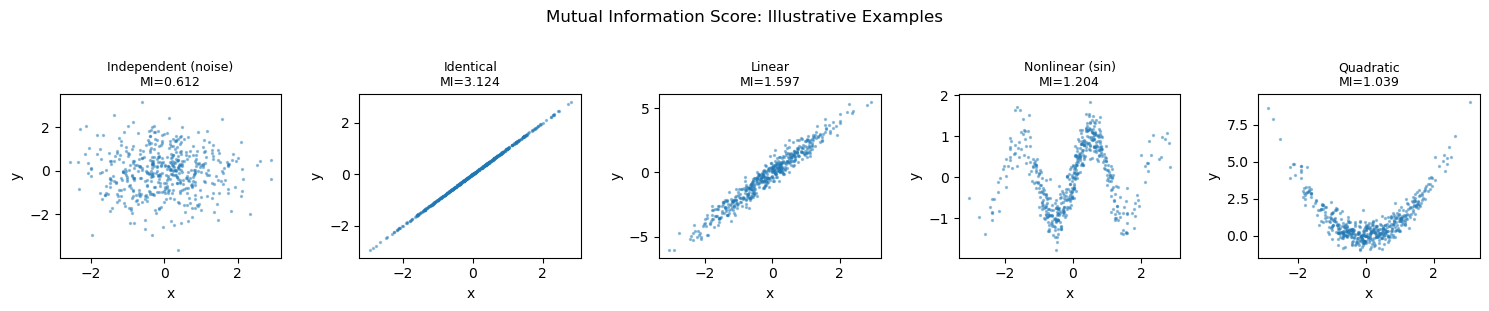

In [15]:
from sklearn.metrics import mutual_info_score
import numpy as np

import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 500
bins = 32

signals = {
    "Independent (noise)": (rng.normal(size=n), rng.normal(size=n)),
    "Identical":           (rng.normal(size=n), lambda x: x),
    "Linear":              (rng.normal(size=n), lambda x: 2*x + 0.5*rng.normal(size=n)),
    "Nonlinear (sin)":     (rng.normal(size=n), lambda x: np.sin(3*x) + 0.3*rng.normal(size=n)),
    "Quadratic":           (rng.normal(size=n), lambda x: x**2 + 0.5*rng.normal(size=n)),
}

# Resolve lambdas
resolved = {}
for name, (x_base, y_val) in signals.items():
    y_base = y_val(x_base) if callable(y_val) else y_val
    resolved[name] = (x_base, y_base)

def compute_mi(x1, x2, bins=32):
    bx = np.histogram_bin_edges(x1, bins=bins)
    by = np.histogram_bin_edges(x2, bins=bins)
    dx = np.digitize(x1, bx)
    dy = np.digitize(x2, by)
    return mutual_info_score(dx, dy)

fig, axes = plt.subplots(1, len(resolved), figsize=(15, 3))

for ax, (name, (x1, x2)) in zip(axes, resolved.items()):
    mi = compute_mi(x1, x2, bins=bins)
    ax.scatter(x1, x2, s=2, alpha=0.4)
    ax.set_title(f"{name}\nMI={mi:.3f}", fontsize=9)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Mutual Information Score: Illustrative Examples", y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the examples

The examples above show how `mutual_info_score` changes depending on the relationship between two variables.

- **Independent (noise)**  
    Here, $x$ and $y$ are generated independently.  
    Knowing $x$ gives almost no information about $y$, so the mutual information is close to $0$.

- **Identical**  
    Here, $y=x$.  
    Once $x$ is known, $y$ is known exactly, so the mutual information is large.

- **Linear**  
    Here, $y \approx 2x + \text{noise}$.  
    There is a clear dependence between the variables, so the mutual information is positive and usually fairly large.

- **Nonlinear (sin)**  
    Here, $y \approx \sin(3x) + \text{noise}$.  
    The dependence is nonlinear, so ordinary correlation may miss part of the structure, but mutual information can still detect it.

- **Quadratic**  
    Here, $y \approx x^2 + \text{noise}$.  
    This is another nonlinear relationship. Mutual information remains useful because it does not assume linearity.

### What the scatter plots show

Each scatter plot gives a visual picture of dependence:

- a diffuse cloud suggests weak dependence,
- a narrow line or curve suggests strong dependence,
- curved shapes can still have high mutual information even when linear correlation is small.

### Important note

The exact mutual information values depend on:

- the number of bins,
- the sample size,
- the noise level.

So the score is most useful for **comparison across delays or examples**, rather than as an absolute quantity on its own.

In [16]:

def average_mutual_information(x, max_lag, bins=32):
    """
    Compute Average Mutual Information (AMI) between x(t) and x(t+tau).

    Parameters
    ----------
    x : array-like
        1D input time series.
    max_lag : int
        Maximum lag (exclusive). AMI is computed for tau = 1, ..., max_lag-1.
    bins : int, default=32
        Number of bins used to discretize each delayed variable.

    Returns
    -------
    np.ndarray
        AMI values for lags 1..max_lag-1.
    """
    x = np.asarray(x, dtype=float).ravel()

    if x.size < 2:
        raise ValueError("x must contain at least 2 samples.")
    if not isinstance(max_lag, (int, np.integer)) or max_lag <= 1:
        raise ValueError("max_lag must be an integer greater than 1.")
    if not isinstance(bins, (int, np.integer)) or bins < 2:
        raise ValueError("bins must be an integer >= 2.")

    max_lag = min(max_lag, x.size)
    ami = []
    for tau in range(1, max_lag):
        x1 = x[:-tau]
        x2 = x[tau:]

        # bin data
        bins_x1 = np.histogram_bin_edges(x1, bins=bins)
        bins_x2 = np.histogram_bin_edges(x2, bins=bins)

        digitized_x1 = np.digitize(x1, bins_x1)
        digitized_x2 = np.digitize(x2, bins_x2)

        ami.append(mutual_info_score(digitized_x1, digitized_x2))
    return np.array(ami)


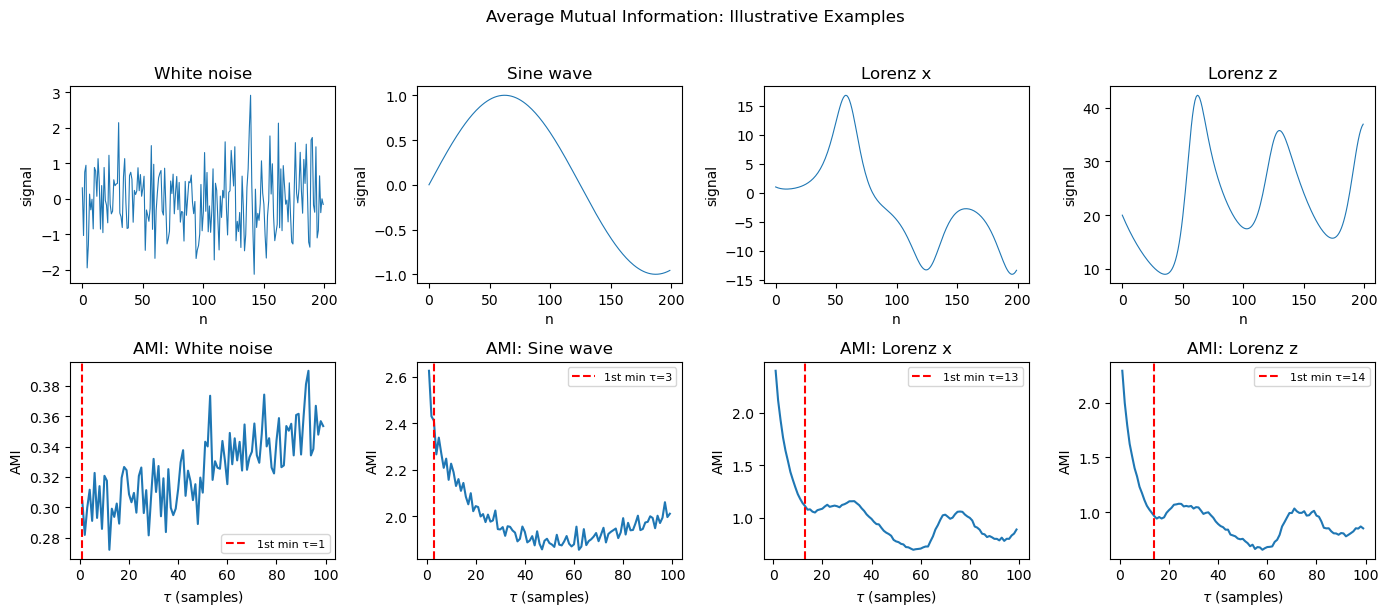

In [17]:

# Illustrative examples of Average Mutual Information for different signal types

n = 1000
max_lag = 100
rng = np.random.default_rng(42)

example_signals = {
    "White noise": rng.normal(size=n),
    "Sine wave": np.sin(np.linspace(0, 8 * np.pi, n)),
    "Lorenz x": x_lorenz[:n],
    "Lorenz z": z_lorenz[:n],
}

fig, axes = plt.subplots(2, len(example_signals), figsize=(14, 6))

for col, (name, sig) in enumerate(example_signals.items()):
    # Plot signal
    axes[0, col].plot(sig[:200], lw=0.8)
    axes[0, col].set_title(name)
    axes[0, col].set_xlabel("n")
    axes[0, col].set_ylabel("signal")

    # Compute and plot AMI
    ami_sig = average_mutual_information(sig, max_lag)
    axes[1, col].plot(range(1, max_lag), ami_sig, lw=1.5)
    axes[1, col].set_xlabel(r"$\tau$ (samples)")
    axes[1, col].set_ylabel("AMI")
    axes[1, col].set_title(f"AMI: {name}")

    # Mark first local minimum
    d = np.diff(ami_sig)
    min_idx = np.where((d[:-1] < 0) & (d[1:] > 0))[0]
    if len(min_idx) > 0:
        m = int(min_idx[0]) + 1
        axes[1, col].axvline(m, color='r', linestyle='--', label=f'1st min τ={m}')
        axes[1, col].legend(fontsize=8)

plt.suptitle("Average Mutual Information: Illustrative Examples", y=1.02)
plt.tight_layout()
plt.show()

Use it on our Lorenz solution

First local minimum of AMI at lag: 17 (0-indexed: 16)
AMI value at minimum: 0.89014
Delay in time units: 0.17

First lag where AMI <= AMI[0]/e: 14 (0-indexed: 13)
AMI[0]/e threshold: 0.92625
AMI value there: 0.92074
Delay in time units: 0.14


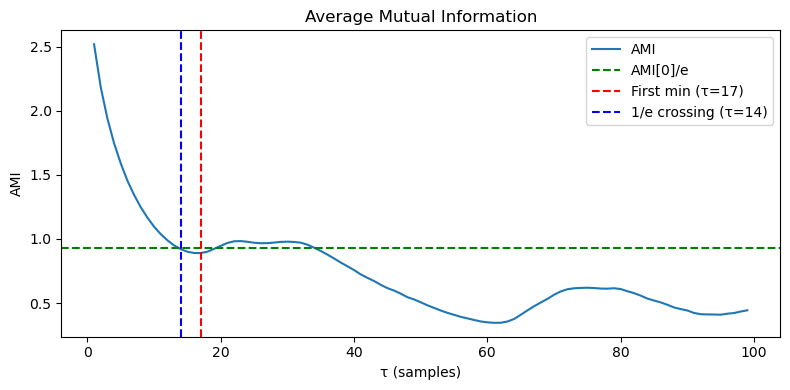

In [18]:
ts=x_lorenz # normalize to zero mean and unit variance
ami=average_mutual_information(ts, max_lag)
# First local minimum of AMI
d_ami = np.diff(ami)
ami_min_idx = np.where((d_ami[:-1] < 0) & (d_ami[1:] > 0))[0] + 1

if len(ami_min_idx) == 0:
    print("No local minimum found in AMI.")
else:
    first_ami_min = int(ami_min_idx[0])
    print(f"First local minimum of AMI at lag: {first_ami_min + 1} (0-indexed: {first_ami_min})")
    print(f"AMI value at minimum: {ami[first_ami_min]:.5f}")
    print(f"Delay in time units: {(first_ami_min + 1) * dt:.2f}")

# 1/e reduction of AMI
ami_threshold = ami[0] / np.e
inv_e_idx = np.where(ami <= ami_threshold)[0]

if len(inv_e_idx) == 0:
    print("AMI never drops to 1/e of its initial value.")
else:
    first_inv_e = int(inv_e_idx[0])
    print(f"\nFirst lag where AMI <= AMI[0]/e: {first_inv_e + 1} (0-indexed: {first_inv_e})")
    print(f"AMI[0]/e threshold: {ami_threshold:.5f}")
    print(f"AMI value there: {ami[first_inv_e]:.5f}")
    print(f"Delay in time units: {(first_inv_e + 1) * dt:.2f}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, max_lag), ami, label='AMI')
plt.axhline(ami_threshold, color='g', linestyle='--', label='AMI[0]/e')
plt.axvline(first_ami_min + 1, color='r', linestyle='--', label=f'First min (τ={first_ami_min+1})')
plt.axvline(first_inv_e + 1, color='b', linestyle='--', label=f'1/e crossing (τ={first_inv_e+1})')
plt.xlabel("τ (samples)")
plt.ylabel("AMI")
plt.title("Average Mutual Information")
plt.legend()
plt.tight_layout()
plt.show()

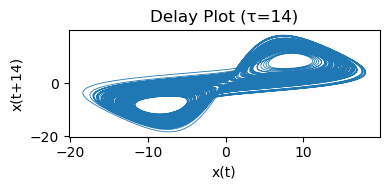

In [19]:
tau=14
plt.figure(figsize=(4, 2))
plt.plot( ts[:-tau], ts[tau:], lw=0.6)
plt.xlabel("x(t)")
plt.ylabel(f"x(t+{tau})")
plt.title(f"Delay Plot (τ={tau})")
plt.tight_layout()
plt.show()

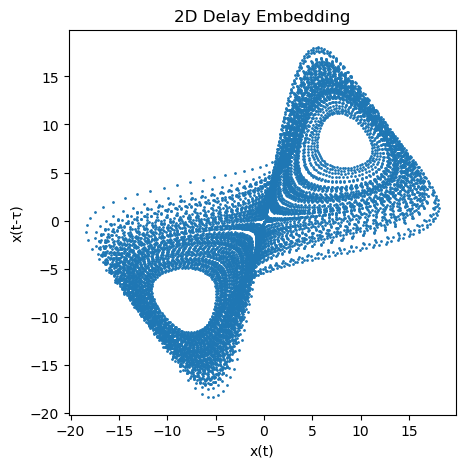

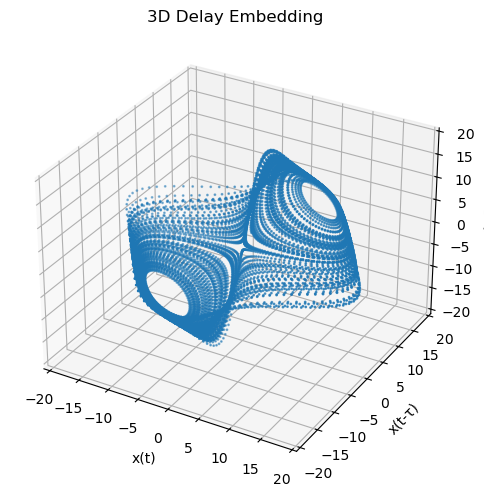

In [20]:
tau = 17  # example from AMI
Y1 = delay_embedding(x_lorenz, tau, m=1)
Y2 = delay_embedding(x_lorenz, tau, m=2)
Y3 = delay_embedding(x_lorenz, tau, m=3)

plt.figure(figsize=(5,5))
plt.scatter(Y2[:,0], Y2[:,1], s=1)
plt.xlabel("x(t)")
plt.ylabel("x(t-τ)")
plt.title("2D Delay Embedding")
plt.show()
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6, 5))
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    get_ipython().run_line_magic("matplotlib", "inline")
ax = fig.add_subplot(111, projection="3d")
ax.scatter(Y3[:,0], Y3[:,1], Y3[:,2], s=1)
ax.set_xlabel("x(t)")
ax.set_ylabel("x(t-τ)")
ax.set_zlabel("x(t-2τ)")
ax.set_title("3D Delay Embedding")
plt.tight_layout()
plt.show()

# The embedding dimension

## False Nearest Neighbours

False Nearest Neighbours (FNN) is a practical method for choosing the embedding dimension $m$ in delay-coordinate reconstruction.

The idea is simple: in a dimension that is too low, points can appear to be close only because the attractor has been projected onto an insufficient space. These are **false neighbours**. When the embedding dimension is increased, such artificial neighbours separate, while true neighbours remain close.

So the FNN procedure is:

1. build the delay embedding with dimension $m$,
2. find nearest neighbours of each point,
3. check whether those neighbours stay close when moving to dimension $m+1$,
4. compute the percentage of neighbours that turn out to be false.

A good embedding dimension is usually the smallest $m$ for which the percentage of false nearest neighbours becomes very small or close to zero.

In [21]:
from sklearn.neighbors import NearestNeighbors
#help(NearestNeighbors)

In [22]:
resolved.keys()

dict_keys(['Independent (noise)', 'Identical', 'Linear', 'Nonlinear (sin)', 'Quadratic'])

Example 1: k-nearest neighbors
Query index: 0, point: [0.55307679 0.43249619]
  Neighbor 1: index=0, distance=0.0000, point=[0.55307679 0.43249619]
  Neighbor 2: index=177, distance=0.0448, point=[0.50865954 0.42704638]
  Neighbor 3: index=336, distance=0.0494, point=[0.55433    0.38307668]
  Neighbor 4: index=366, distance=0.0674, point=[0.51013872 0.48439636]
  Neighbor 5: index=196, distance=0.0736, point=[0.49527295 0.38693869]

Example 2: radius neighbors
  Point 0: 23 neighbors within radius 0.25
  Point 50: 6 neighbors within radius 0.25
  Point 100: 20 neighbors within radius 0.25

Example 3: metric comparison (k=5, query=0)
  Metric=euclidean  -> neighbor indices=[0, 177, 336, 366, 196]
  Metric=manhattan  -> neighbor indices=[0, 177, 336, 366, 196]
  Metric=cosine     -> neighbor indices=[0, 196, 87, 5, 14]


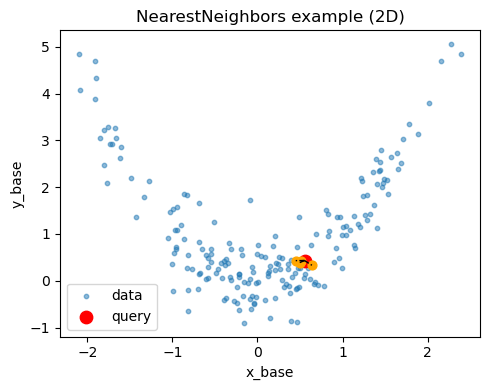

In [23]:
# Examples using NearestNeighbors

# Build a 2D dataset from existing variables
n = min(len(x_base), len(y_base))
X2 = np.column_stack([x_base[:n], y_base[:n]])

# --- Example 1: k-nearest neighbors for one query point ---
k = 5
nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn.fit(X2)

query_idx = 0
distances, indices = nn.kneighbors(X2[query_idx].reshape(1, -1))

print("Example 1: k-nearest neighbors")
print(f"Query index: {query_idx}, point: {X2[query_idx]}")
for rank, (j, d) in enumerate(zip(indices[0], distances[0]), start=1):
    print(f"  Neighbor {rank}: index={j}, distance={d:.4f}, point={X2[j]}")

# --- Example 2: neighbors within a radius ---
r = 0.25
nn_r = NearestNeighbors(radius=r, metric="euclidean")
nn_r.fit(X2)

sample_ids = [0, 50, 100]
print("\nExample 2: radius neighbors")
for i in sample_ids:
    idx_r = nn_r.radius_neighbors(X2[i].reshape(1, -1), return_distance=False)[0]
    print(f"  Point {i}: {len(idx_r)} neighbors within radius {r}")

# --- Example 3: compare metrics on the same query ---
metrics = ["euclidean", "manhattan", "cosine"] # add more if desired
print("\nExample 3: metric comparison (k=5, query=0)")
for m in metrics:
    nn_m = NearestNeighbors(n_neighbors=5, metric=m)
    nn_m.fit(X2)
    d_m, i_m = nn_m.kneighbors(X2[query_idx].reshape(1, -1))
    print(f"  Metric={m:10s} -> neighbor indices={i_m[0].tolist()}")

# Optional quick visualization for Example 1
subset = 200
Xv = X2[:subset]

nn_v = NearestNeighbors(n_neighbors=5)
nn_v.fit(Xv)
d_v, i_v = nn_v.kneighbors(Xv[query_idx].reshape(1, -1))

plt.figure(figsize=(5, 4))
plt.scatter(Xv[:, 0], Xv[:, 1], s=10, alpha=0.5, label="data")
plt.scatter(Xv[query_idx, 0], Xv[query_idx, 1], s=80, c="red", label="query")

for j in i_v[0][1:]:
    plt.plot(
        [Xv[query_idx, 0], Xv[j, 0]],
        [Xv[query_idx, 1], Xv[j, 1]],
        "k--",
        lw=1
    )
    plt.scatter(Xv[j, 0], Xv[j, 1], s=40, c="orange")

plt.xlabel("x_base")
plt.ylabel("y_base")
plt.title("NearestNeighbors example (2D)")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:


def false_nearest_neighbors(x, tau, max_dim, R_tol=10.0):
    """
    Compute the False Nearest Neighbors (FNN) percentage curve.

    Parameters
    ----------
    x : array-like
        1D scalar time series.
    tau : int
        Delay in samples.
    max_dim : int
        Maximum embedding dimension tested (computes for m=1..max_dim-1).
    R_tol : float, default=10.0
        Distance-ratio threshold to label a neighbor as false.

    Returns
    -------
    np.ndarray
        Percentage of false neighbors for each tested dimension.
    """
    x = np.asarray(x, dtype=float).ravel()
    tau = int(tau)
    max_dim = int(max_dim)

    if x.size < 3:
        raise ValueError("x must contain at least 3 samples.")
    if tau <= 0:
        raise ValueError("tau must be a positive integer.")
    if max_dim <= 1:
        raise ValueError("max_dim must be greater than 1.")
    if x.size - (max_dim - 1) * tau < 2:
        raise ValueError("Not enough samples for the requested tau and max_dim.")
    fnn_percent = []

    for m in range(1, max_dim):
        Y_m   = delay_embedding(x, tau, m)
        Y_mp1 = delay_embedding(x, tau, m+1)

        # Only keep points that exist in both embeddings
        N = len(Y_mp1)
        Y_m = Y_m[:N]

        nbrs = NearestNeighbors(n_neighbors=2).fit(Y_m)
        distances, indices = nbrs.kneighbors(Y_m)

        false_neighbors = 0

        for i in range(N):
            nn_index = indices[i, 1]
            dist_m = distances[i, 1]

            dist_mp1 = abs(
                Y_mp1[i, -1] - Y_mp1[nn_index, -1]
            )

            if dist_m > 0 and dist_mp1 / dist_m > R_tol:
                false_neighbors += 1

        fnn_percent.append(false_neighbors / N * 100)

    return np.array(fnn_percent)

On our Lorenz data.

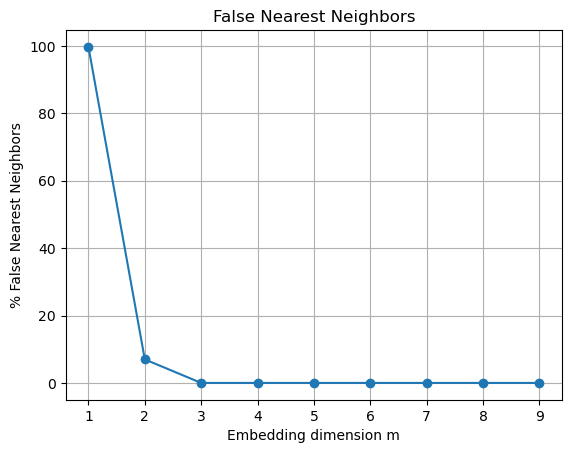

In [25]:
max_dim = 10
fnn = false_nearest_neighbors(x_lorenz, tau, max_dim)

plt.plot(range(1, max_dim), fnn, marker='o')
plt.xlabel("Embedding dimension m")
plt.ylabel("% False Nearest Neighbors")
plt.title("False Nearest Neighbors")
plt.grid(True)
plt.show()

Now all together on the Lorenz example

Series: x_lorenz
AMI first local minimum delay: tau = 17 samples (~0.170 time units)
AMI(tau): 0.89014
FNN curve (%), m=1..11:
[99.675  6.978  0.     0.     0.     0.     0.     0.     0.     0.
  0.   ]
Suggested embedding dimension: m = 3 (first with FNN < 1.0%)


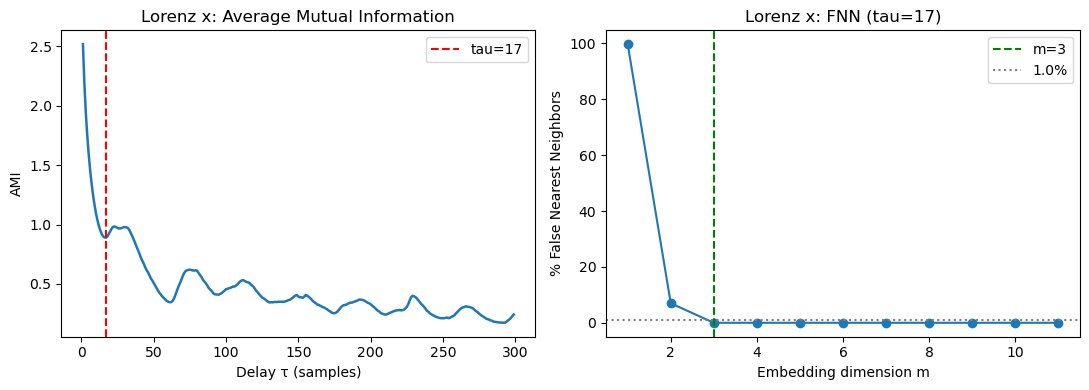

Selected delay tau = 17
Selected embedding dimension m = 3
Embedded shape: (11966, 3)
First 5 vectors:
 [[0.2068394  0.18612886 0.48182136]
 [0.1952599  0.19291107 0.51892074]
 [0.18570751 0.20054384 0.55964847]
 [0.17795433 0.20907977 0.60431773]
 [0.17180016 0.21858224 0.65325164]]


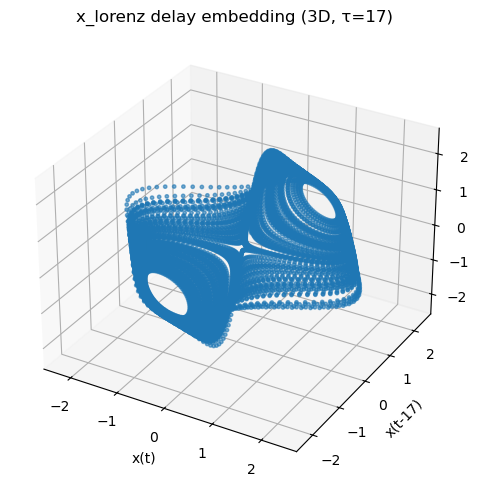

In [30]:
# Full MI + FNN workflow on one Lorenz observable (x_lorenz)

series_name = "x_lorenz"
series = np.asarray(x_lorenz, dtype=float)
series = (series - series.mean()) / series.std()

# --- MI / AMI ---
max_lag_lorenz = 300
bins_lorenz = 32
ami_lorenz = average_mutual_information(series, max_lag=max_lag_lorenz, bins=bins_lorenz)

d_ami = np.diff(ami_lorenz)
min_idx = np.where((d_ami[:-1] < 0) & (d_ami[1:] > 0))[0] + 1  # ami index
if len(min_idx) > 0:
    tau_mi = int(min_idx[0] + 1)  # lag value
else:
    tau_mi = int(np.argmin(ami_lorenz[:100]) + 1)  # fallback

# --- FNN ---
max_dim_lorenz = 12
fnn_lorenz = false_nearest_neighbors(series, tau=tau_mi, max_dim=max_dim_lorenz, R_tol=10.0)

threshold = 1.0  # %
idx_m = np.where(fnn_lorenz < threshold)[0]
m_star = int(idx_m[0] + 1) if len(idx_m) > 0 else None

# Robust Lorenz dt estimate
lorenz_dt = float(np.mean(np.diff(t))) if ("t" in globals() and len(t) == len(x_lorenz)) else 0.01

# --- Results ---
print(f"Series: {series_name}")
print(f"AMI first local minimum delay: tau = {tau_mi} samples (~{tau_mi * lorenz_dt:.3f} time units)")
print(f"AMI(tau): {ami_lorenz[tau_mi - 1]:.5f}")
print(f"FNN curve (%), m=1..{max_dim_lorenz-1}:")
print(np.round(fnn_lorenz, 3))

if m_star is not None:
    print(f"Suggested embedding dimension: m = {m_star} (first with FNN < {threshold}%)")
else:
    print(f"No dimension reached FNN < {threshold}% up to m={max_dim_lorenz-1}")

# --- Plots ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# AMI
ax[0].plot(np.arange(1, max_lag_lorenz), ami_lorenz, lw=1.8)
ax[0].axvline(tau_mi, color="r", linestyle="--", label=f"tau={tau_mi}")
ax[0].set_xlabel("Delay τ (samples)")
ax[0].set_ylabel("AMI")
ax[0].set_title("Lorenz x: Average Mutual Information")
ax[0].legend()

# FNN
dims = np.arange(1, max_dim_lorenz)
ax[1].plot(dims, fnn_lorenz, marker="o")
if m_star is not None:
    ax[1].axvline(m_star, color="g", linestyle="--", label=f"m={m_star}")
ax[1].axhline(threshold, color="gray", linestyle=":", label=f"{threshold}%")
ax[1].set_xlabel("Embedding dimension m")
ax[1].set_ylabel("% False Nearest Neighbors")
ax[1].set_title(f"Lorenz x: FNN (tau={tau_mi})")
ax[1].legend()

plt.tight_layout()
plt.show()


# 3) Build embeddings
Y2 = delay_embedding(series, tau=tau_mi, m=2)
Y3 = delay_embedding(series, tau=tau_mi, m=3)
Ym = delay_embedding(series, tau=tau_mi, m=m_star)

print(f"Selected delay tau = {tau_mi}")
print(f"Selected embedding dimension m = {m_star}")
print("Embedded shape:", Ym.shape)
print("First 5 vectors:\n", Ym[:5])



# 3D embedding
fig = plt.figure(figsize=(6, 5))
ax3 = fig.add_subplot(111, projection="3d")
ax3.scatter(Ym[:, 0], Ym[:, 1], Ym[:, 2], s=6, alpha=0.6)
ax3.set_xlabel("x(t)")
ax3.set_ylabel(f"x(t-{tau_mi})")
ax3.set_zlabel(f"x(t-{2*tau_mi})")
ax3.set_title(f"{series_name} delay embedding (3D, τ={tau_mi})")
plt.tight_layout()
plt.show()

In [29]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=Ym[:, 0],
            y=Ym[:, 1],
            z=Ym[:, 2],
            mode="markers",
            marker=dict(
                size=2,
                color=np.arange(len(Ym)),  # color by index
                colorbar=dict(title="index"),
                colorscale="Viridis",
                opacity=0.6,
            ),
        )
    ]
)
ax3.set_xlabel("x(t)")
ax3.set_ylabel(f"x(t+{tau_mi})")
ax3.set_zlabel(f"x(t+{2*tau_mi})")
ax3.set_title(f"{series_name} delay embedding (3D, τ={tau_mi})")
fig.update_layout(
    scene=dict(
        xaxis_title='x(t)',
        yaxis_title=f'x(t-{tau_mi})',
        zaxis_title=f'x(t-{2*tau_mi})'
    ),
    title=f"{series_name} delay embedding (3D, τ={tau_mi})",
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# Rösler


In [33]:
def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return [dx, dy, dz]


In [34]:
# Time parameters
t_span = (0, 300)
dt = 0.05
t_eval = np.arange(t_span[0], t_span[1], dt)

# Initial condition
x0 = [1.0, 0.0, 0.0]

sol = solve_ivp(
    rossler,
    t_span,
    x0,
    t_eval=t_eval,
    method="RK45"
)

x_ros, y_ros, z_ros = sol.y

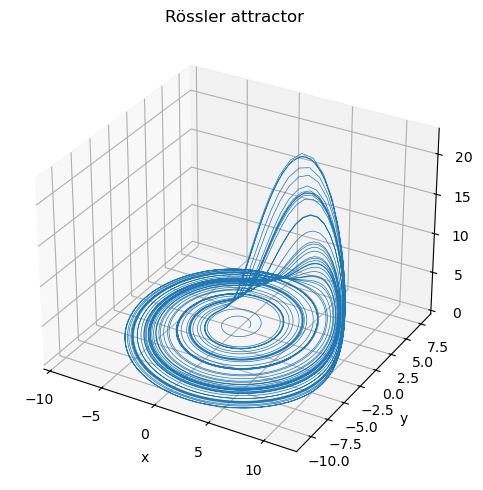

In [35]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_ros, y_ros, z_ros, lw=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Rössler attractor")

plt.tight_layout()
plt.show()

In [53]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x_ros,
            y=y_ros,
            z=z_ros,
            mode="markers",
            marker=dict(
                size=2,
                color=np.arange(len(x_ros)),  # color by index
                colorbar=dict(title="index"),
                colorscale="Viridis",
                opacity=0.6,
            ),
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z'
    ),
    title='Rössler attractor (interactive)',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

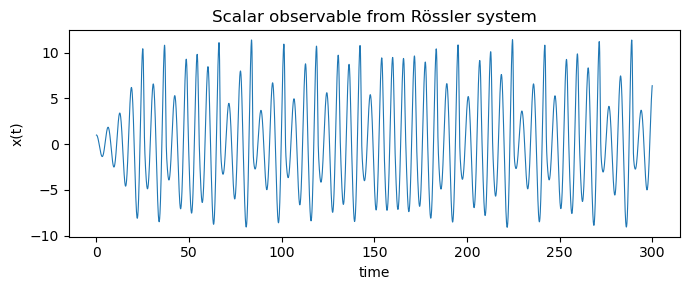

In [54]:
ts_ros = x_ros
plt.figure(figsize=(7,3))
plt.plot(sol.t, ts_ros, lw=0.8)
plt.xlabel("time")
plt.ylabel("x(t)")
plt.title("Scalar observable from Rössler system")
plt.tight_layout()
plt.show()


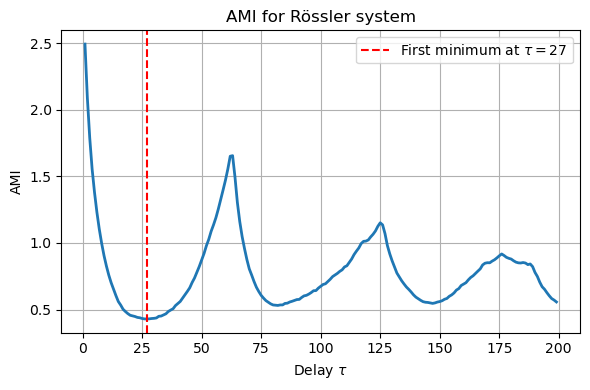

In [55]:
import matplotlib.pyplot as plt

max_lag = 200
ami = average_mutual_information(ts_ros, max_lag)


# crude first-minimum detector
tau_opt = np.argmin(ami[:100]) + 1

plt.figure(figsize=(6,4))
plt.plot(range(1, max_lag), ami, lw=2)
plt.axvline(tau_opt, color="r", linestyle="--",
            label=fr"First minimum at $\tau={tau_opt}$")
plt.xlabel(r"Delay $\tau$")
plt.ylabel("AMI")
plt.title("AMI for Rössler system")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Check with autocorrelation

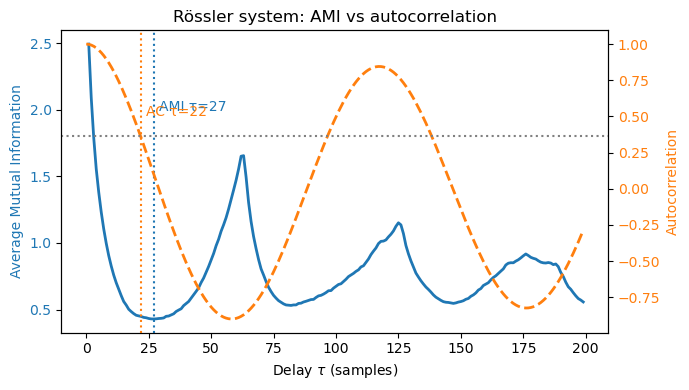

In [56]:
max_lag = 200

ami = average_mutual_information(ts_ros, max_lag)
ac  = autocorrelation(ts_ros, max_lag)
import matplotlib.pyplot as plt

lags_ami = np.arange(1, max_lag)
lags_ac  = np.arange(0, max_lag)

fig, ax1 = plt.subplots(figsize=(7,4))

# AMI (left axis)
ax1.plot(lags_ami, ami, color="C0", lw=2, label="AMI")
ax1.set_xlabel(r"Delay $\tau$ (samples)")
ax1.set_ylabel("Average Mutual Information", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

# Autocorrelation (right axis)
ax2 = ax1.twinx()
ax2.plot(lags_ac, ac, color="C1", lw=2, linestyle="--",
         label="Autocorrelation")
ax2.set_ylabel("Autocorrelation", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

# Reference lines
ax2.axhline(1/np.e, color="gray", linestyle=":", label=r"$1/e$")
tau_ami = np.argmin(ami[:100]) + 1
tau_ac  = np.where(ac < 1/np.e)[0][0]

ax1.axvline(tau_ami, color="C0", linestyle=":")
ax1.text(tau_ami+2, max(ami)*0.8, f"AMI τ={tau_ami}", color="C0")

ax2.axvline(tau_ac, color="C1", linestyle=":")
ax2.text(tau_ac+2, 0.5, f"AC τ={tau_ac}", color="C1")
# Titles and layout
plt.title("Rössler system: AMI vs autocorrelation")
fig.tight_layout()
plt.show()



### FNN on Rösler

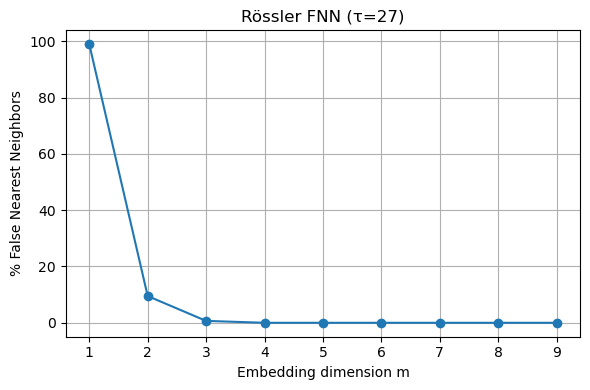

Suggested embedding dimension: m = 3 (FNN < 1.0%)


In [57]:
# False Nearest Neighbors (FNN) for Rössler using AMI-based delay
tau_rossler = int(tau_opt)  # from previous AMI analysis
max_dim_rossler = 10

fnn_rossler = false_nearest_neighbors(ts_ros, tau_rossler, max_dim_rossler)

plt.figure(figsize=(6, 4))
plt.plot(range(1, max_dim_rossler), fnn_rossler, marker="o")
plt.xlabel("Embedding dimension m")
plt.ylabel("% False Nearest Neighbors")
plt.title(f"Rössler FNN (τ={tau_rossler})")
plt.grid(True)
plt.tight_layout()
plt.show()

# First dimension where FNN is effectively near zero
threshold = 1.0  # %
idx = np.where(fnn_rossler < threshold)[0]
if len(idx) > 0:
    print(f"Suggested embedding dimension: m = {idx[0] + 1} (FNN < {threshold}%)")
else:
    print("No dimension found with FNN below threshold in tested range.")

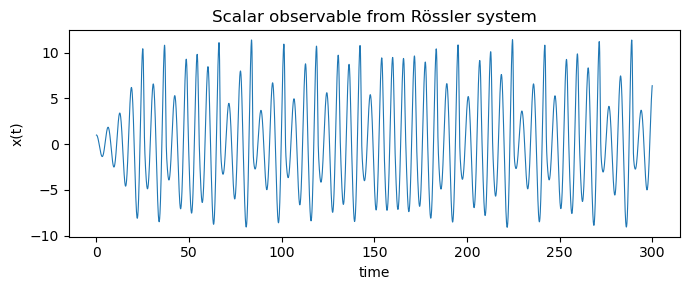

Using tau = 27, m = 3
Embedded shape: (5946, 3)
First 5 embedded vectors:
 [[ 1.          0.11110088 -1.24005782]
 [ 0.99851471  0.05416129 -1.26510883]
 [ 0.99411135 -0.00344983 -1.28721496]
 [ 0.98686033 -0.06159485 -1.30629278]
 [ 0.97681891 -0.12013542 -1.32226186]]


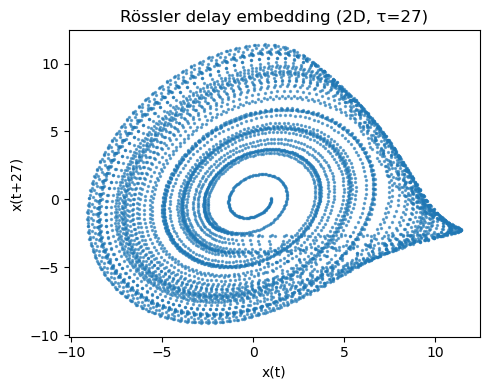

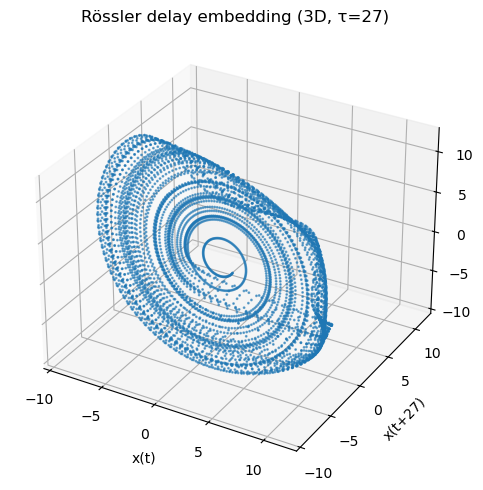

In [58]:
plt.figure(figsize=(7,3))
plt.plot(sol.t, ts_ros, lw=0.8)
plt.xlabel("time")
plt.ylabel("x(t)")
plt.title("Scalar observable from Rössler system")
plt.tight_layout()
plt.show()

# Delay embedding for current series x (Rössler in your latest cells)
tau_use = int(tau_rossler) if "tau_rossler" in globals() else int(tau)
m_use = int(np.where(fnn_rossler < threshold)[0][0] + 1) if "fnn_rossler" in globals() else 3

Y_emb = delay_embedding(ts_ros, tau=tau_use, m=m_use)
Y2_rossler = delay_embedding(ts_ros, tau=tau_use, m=2)
Y3_rossler = delay_embedding(ts_ros, tau=tau_use, m=3)

print(f"Using tau = {tau_use}, m = {m_use}")
print("Embedded shape:", Y_emb.shape)
print("First 5 embedded vectors:\n", Y_emb[:5])

# 2D embedding
plt.figure(figsize=(5, 4))
plt.scatter(Y2_rossler[:, 0], Y2_rossler[:, 1], s=2, alpha=0.6)
plt.xlabel("x(t)")
plt.ylabel(f"x(t+{tau_use})")
plt.title(f"Rössler delay embedding (2D, τ={tau_use})")
plt.tight_layout()
plt.show()

# 3D embedding
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(Y3_rossler[:, 0], Y3_rossler[:, 1], Y3_rossler[:, 2], s=1, alpha=0.6)
ax.set_xlabel("x(t)")
ax.set_ylabel(f"x(t+{tau_use})")
ax.set_zlabel(f"x(t+{2*tau_use})")
ax.set_title(f"Rössler delay embedding (3D, τ={tau_use})")
plt.tight_layout()
plt.show()

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=Y3_rossler[:, 0],
            y=Y3_rossler[:, 1],
            z=Y3_rossler[:, 2],
            mode="markers",
            marker=dict(
                size=2,
                color=Y3_rossler[:, 0],  # optional coloring
                colorscale="Viridis",
                opacity=0.6,
            ),
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title='x(t)',
        yaxis_title='x(t-τ)',
        zaxis_title='x(t-2τ)'
    ),
    title='Takens embedding (interactive)',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# Henon maps

Hénon Takens parameters: tau=1, suggested m=2
FNN (%): [80.648  0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.   ]


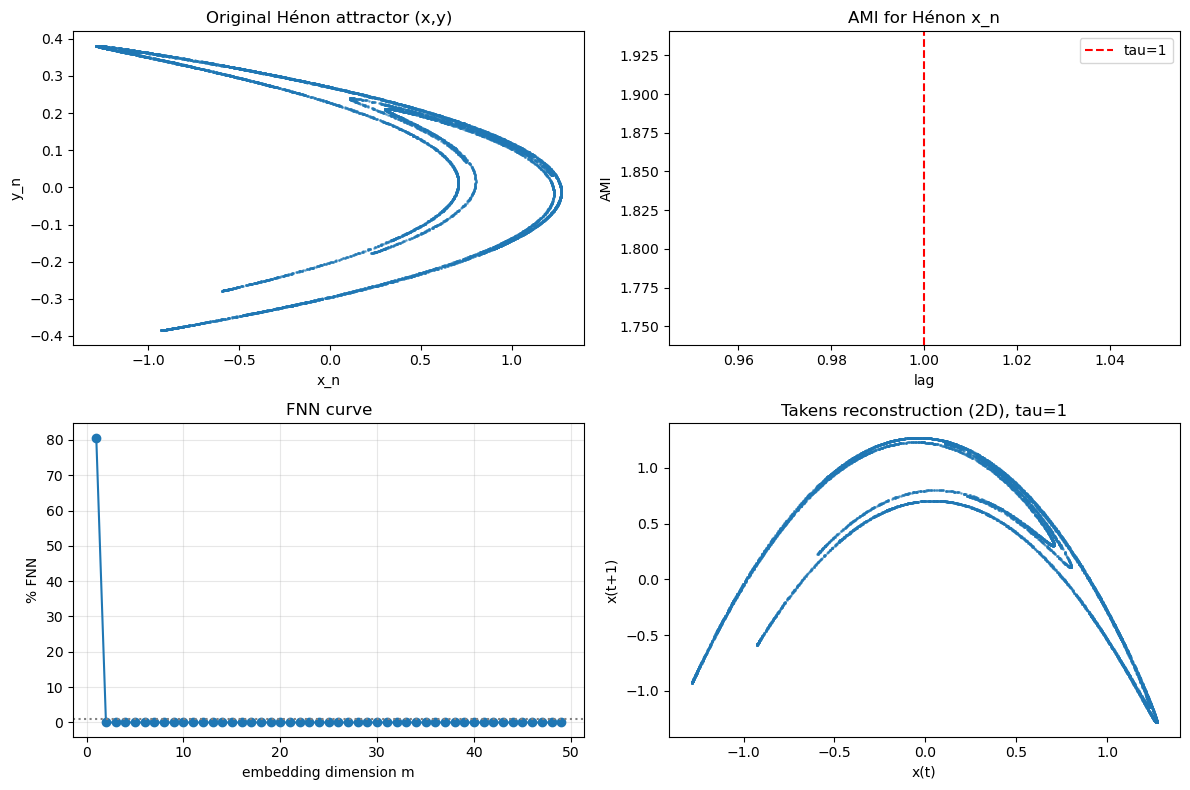

In [59]:
# Takens embedding example on the Hénon map

def henon_map(n=12000, a=1.4, b=0.3, x0=0.1, y0=0.0):
    x = np.empty(n)
    y = np.empty(n)
    x[0], y[0] = x0, y0
    for i in range(n - 1):
        x[i + 1] = 1 - a * x[i] ** 2 + y[i]
        y[i + 1] = b * x[i]
    return x, y

# Generate data and remove transient
x_henon, y_henon = henon_map()
burn = 2000
ts_henon = x_henon[burn:]

# Choose delay from AMI (first local minimum; fallback to argmin on early lags)
max_lag_henon = 2
ami_henon = average_mutual_information(ts_henon, max_lag=max_lag_henon, bins=32)
d_ami_h = np.diff(ami_henon)
mins_h = np.where((d_ami_h[:-1] < 0) & (d_ami_h[1:] > 0))[0] + 1
tau_henon = int(mins_h[0] + 1) if len(mins_h) else int(np.argmin(ami_henon[:20]) + 1)

# Choose embedding dimension from FNN
max_dim_henon = 50
#max_dim_henon = 2
fnn_henon = false_nearest_neighbors(ts_henon, tau=tau_henon, max_dim=max_dim_henon, R_tol=10.0)
idx_m = np.where(fnn_henon < 1.0)[0]
m_henon = int(idx_m[0] + 1) if len(idx_m) else 3

# Build embeddings
Y2_henon = delay_embedding(ts_henon, tau=tau_henon, m=2)
Y3_henon = delay_embedding(ts_henon, tau=tau_henon, m=3)

print(f"Hénon Takens parameters: tau={tau_henon}, suggested m={m_henon}")
print("FNN (%):", np.round(fnn_henon, 3))

# Plots
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(x_henon[burn:], y_henon[burn:], s=1, alpha=0.5)
ax1.set_title("Original Hénon attractor (x,y)")
ax1.set_xlabel("x_n")
ax1.set_ylabel("y_n")

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(np.arange(1, max_lag_henon), ami_henon, lw=1.5)
ax2.axvline(tau_henon, color="r", linestyle="--", label=f"tau={tau_henon}")
ax2.set_title("AMI for Hénon x_n")
ax2.set_xlabel("lag")
ax2.set_ylabel("AMI")
ax2.legend()

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(np.arange(1, max_dim_henon), fnn_henon, marker="o")
ax3.axhline(1.0, color="gray", linestyle=":")
ax3.set_title("FNN curve")
ax3.set_xlabel("embedding dimension m")
ax3.set_ylabel("% FNN")
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(Y2_henon[:, 0], Y2_henon[:, 1], s=1, alpha=0.5)
ax4.set_title(f"Takens reconstruction (2D), tau={tau_henon}")
ax4.set_xlabel("x(t)")
ax4.set_ylabel(f"x(t+{tau_henon})")

plt.tight_layout()
plt.show()


fig = go.Figure(
    data=[
        go.Scatter3d(
            x=Y3_henon[:, 0],
            y=Y3_henon[:, 1],
            z=Y3_henon[:, 2],
            mode="markers",
            marker=dict(
                size=2,
                color=Y3_henon[:, 0],  # optional coloring
                colorscale="Viridis",
                opacity=0.6,
            ),
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title='x(t)',
        yaxis_title='x(t-τ)',
        zaxis_title='x(t-2τ)'
    ),
    title='Takens embedding (interactive)',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# Meteostat data
##  Meteostat Data Portal

We will use an open dataset containing relatively recent weather data from around the world. See https://meteostat.net for a general introduction, and https://dev.meteostat.net/python/ for the Python library.

We first install the library (if necessary) and then load it:




In [67]:
%pip install meteostat
# Import Meteostat library
#from meteostat import Stations, Daily, Hourly
%pip install folium
import folium
from IPython.display import display
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from meteostat import stations,daily, hourly,Point


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [76]:
bergen_txt = "Bergen, Norway"
bergen_latlon = (60.392993, 5.324138)  # Latitude and Longitude for Bergen, Norway
latlon = bergen_latlon
number_of_stations = 15 # Number of stations to fetch
# Get nearby weather stations
point=Point(latlon[0], latlon[1])

stations_obj = stations.nearby(point,radius=1000000)#.fetch(number_of_stations)
stations_obj



,name,country,region,latitude,longitude,elevation,timezone,distance
id,,,,,,,,
01317,Bergen / Florida,NO,HO,60.3833,5.3333,12,Europe/Oslo,1189.6
01311,Bergen / Flesland,NO,HO,60.2833,5.2333,5,Europe/Oslo,13181.8
01314,Fossmark / Stanghelle,NO,HO,60.5206,5.7247,10,Europe/Oslo,26146.9
01327,Kvamskogen-jonshogdi / Kleivi,NO,HO,60.3886,5.9639,455,Europe/Oslo,35151.4
01418,Upsanger Lake / Bekkjarvik,NO,HO,60.0167,5.2058,32,Europe/Oslo,42349.6
...,...,...,...,...,...,...,...,...
01480,Drammen Berskog / Konnerudkollen,NO,BU,59.7536,10.1236,8,Europe/Oslo,275505.8
01233,Dombas,NO,34,62.0719,9.1161,638,Europe/Oslo,275653.1
01375,Kvitfjell,NO,OP,61.4833,9.9667,1028,Europe/Oslo,278446.4


In [79]:
# Define the time period for data retrieval
start = datetime(2022, 2, 21) # Start date: February 21, 2022
end = datetime(2022, 3, 1) # End date: March 1, 2022

# Get station IDs for the three selected stations
sid = '01317' # Bergen Florida

# Fetch hourly data for each station and store in a dictionary
hourly_data = {}
data = hourly(sid, start, end).fetch()
hourly_data = data

hourly_data
    

,temp,rhum,prcp,snwd,wdir,wspd,wpgt,pres,tsun,cldc,coco
time,,,,,,,,,,,
2022-02-21 00:00:00,1.9,99,2.4,<NA>,150,10.1,27.0,971.7,<NA>,<NA>,<NA>
2022-02-21 01:00:00,2.6,90,0.4,<NA>,139,7.6,25.2,972.5,<NA>,<NA>,<NA>
2022-02-21 02:00:00,2.7,91,0.2,<NA>,135,12.2,19.1,973.0,<NA>,<NA>,<NA>
2022-02-21 03:00:00,2.6,96,0.2,<NA>,129,6.1,14.4,972.5,<NA>,<NA>,<NA>
2022-02-21 04:00:00,2.8,97,0.1,<NA>,136,5.8,11.9,973.0,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
2022-02-28 20:00:00,4.4,93,1.1,<NA>,164,31.0,60.8,1018.5,<NA>,<NA>,<NA>
2022-02-28 21:00:00,4.6,86,1.0,<NA>,153,21.6,61.2,1018.6,<NA>,8,<NA>
2022-02-28 22:00:00,4.8,93,1.4,<NA>,169,30.6,58.7,1018.1,<NA>,<NA>,<NA>


Your turn. Do Taken's embedding on a chosen time series. The pipeline
- Select a station, start time and end time. 
- Select a time series, you might have to fill gaps and remove outliers. 
- Scale, subtract mean and divide by standard deviation. 
- Find Mutual Information and pick $\tau$
- Find False Nearest Neighbour and pick embedding dimension. 
- Do Taken embedding and see if you can see any patterns. 

Chose different time periods (e.g. summer, winter), time series variables
See if changing $\tau $ and embedding dimension gives different results. 
